# CEDAR : Choosing a Lag Selection Method

CEDAR Phase 0 selects the most predictive lag per variable pair before running any CI test.
Two parameters control this:

- **`lag_method`** — how importance scores are computed  
- **`lag_pvalue_method`** — how significance is tested

This notebook compares options on **ex3** (d=11, T=300) and gives practical guidance on
when to deviate from the defaults.

| `lag_method` | Type | Best when |
|---|---|---|
| `partial_dcor` | Unbiased dcor on Y(t) residualised on Y(t-1) | **Default** — removes AR-mediated lag inflation; best for hub-heavy graphs |
| `dcor` | Unbiased U-centered dcor | General nonlinear |
| `dcor_biased` | Biased distance correlation | Slightly faster than `dcor` |
| `pearson` | Pearson correlation | Confirmed linear data; fastest |
| `granger` | Granger-conditional parcorr | When source AR is strong and inflates lag scores |

| `lag_pvalue_method` | Type | Best when |
|---|---|---|
| `t_test` | Asymptotic t-test, no permutation | **Default** — ~200× faster, n ≥ 20 |
| `circular_shift` | Circular-shift permutation | Strict FPR control on short AR series |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts.synthetic_data.synthetic_datasets import load_dataset
from causalts.ci_tests import PartialCorr
from causalts.cedar import run_cedar
from causalts.utils import evaluate_graph


## Dataset: Cascade Network (ex3, d=11)

d=11 variables, T=300, max_lag=3 — **linear VAR** signaling cascade (all edges are linear weighted sums of lagged values, Gaussian noise). Stationary, no nonstationarity node C.

In [2]:
result = load_dataset("ex3", seed=42, T=300)
df = result["df"]
ground_truth = result["ground_truth"]

print(f"Dataset: {df.shape[0]} × {df.shape[1]} variables")
print(f"Variables: {list(df.columns)}")


Dataset: 300 × 11 variables
Variables: ['Plcg', 'Pip3', 'Pip2', 'PKC', 'PKA', 'P38', 'Jnk', 'Raf', 'Mek', 'Erk', 'Akt']


## 1. Compare `lag_method`

In [3]:
lag_methods = ["pearson", "dcor_biased", "dcor", "partial_dcor", "granger"]
records = []
results_by_method = {}

for lag_method in lag_methods:
    ci = PartialCorr(np.ascontiguousarray(df.values))
    t0 = time.time()
    res = run_cedar(
        df=df, ci_test=ci, max_lag=3,
        lag_method=lag_method,
        alpha_cond1=0.05, alpha_cond2=0.05,
    )
    elapsed = time.time() - t0
    results_by_method[lag_method] = res

    # AR(1) self-loops are included by default (include_autoreg=True)
    # and match the autoregressive ground truth in ex3.
    m = evaluate_graph(res.cg_tig, ground_truth)
    records.append(dict(
        lag_method=lag_method,
        F1=m["F1"], Precision=m["Precision"], Recall=m["TPR"],
        SHD=m["SHD"], TP=m["TP"], FP=m["FP"], FN=m["FN"],
        n_tests=res.n_tests, Time=elapsed,
    ))
    default = " ← default" if lag_method == "partial_dcor" else ""
    print(f"{lag_method:<14} F1={m['F1']:.3f}  Prec={m['Precision']:.3f}  "
          f"Recall={m['TPR']:.3f}  SHD={m['SHD']}  n_tests={res.n_tests}  ({elapsed:.2f}s){default}")

pearson        F1=0.964  Prec=0.964  Recall=0.964  SHD=2  n_tests=194  (0.16s)
dcor_biased    F1=0.945  Prec=0.963  Recall=0.929  SHD=3  n_tests=226  (0.11s)
dcor           F1=0.926  Prec=0.962  Recall=0.893  SHD=4  n_tests=110  (0.07s)
partial_dcor   F1=0.964  Prec=0.964  Recall=0.964  SHD=2  n_tests=194  (0.06s) ← default
granger        F1=0.964  Prec=0.964  Recall=0.964  SHD=2  n_tests=194  (0.06s)


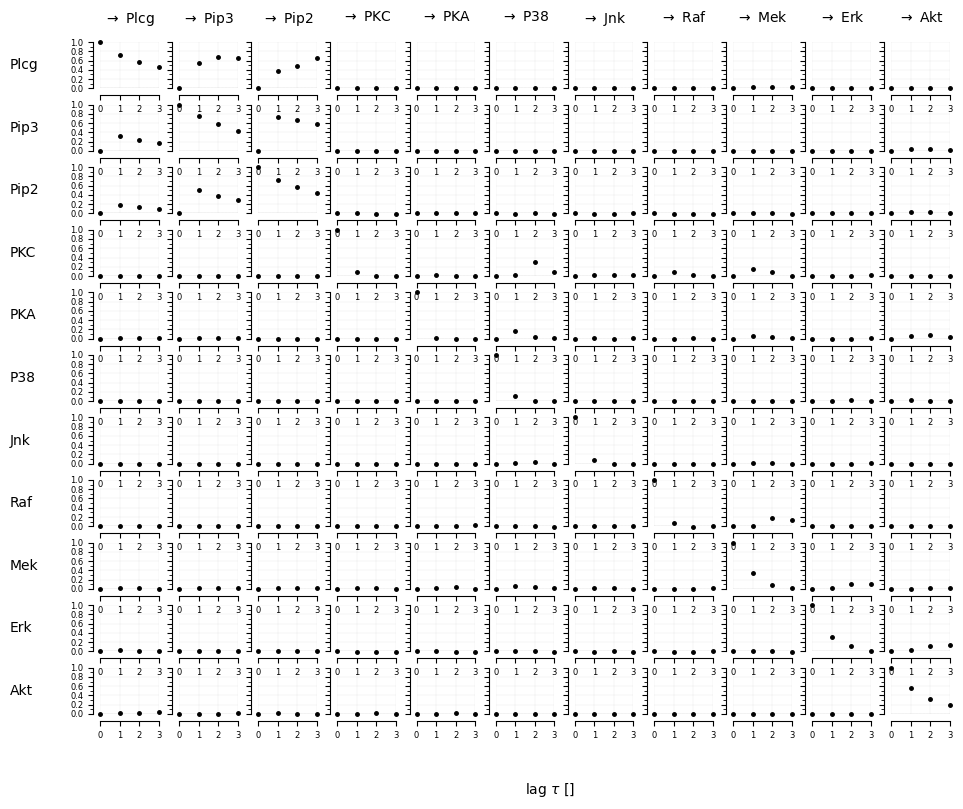

In [4]:
# Lag importance matrix for the default dcor result
results_by_method["dcor"].plot_lag_importance(figsize=(10, 8))
plt.show()


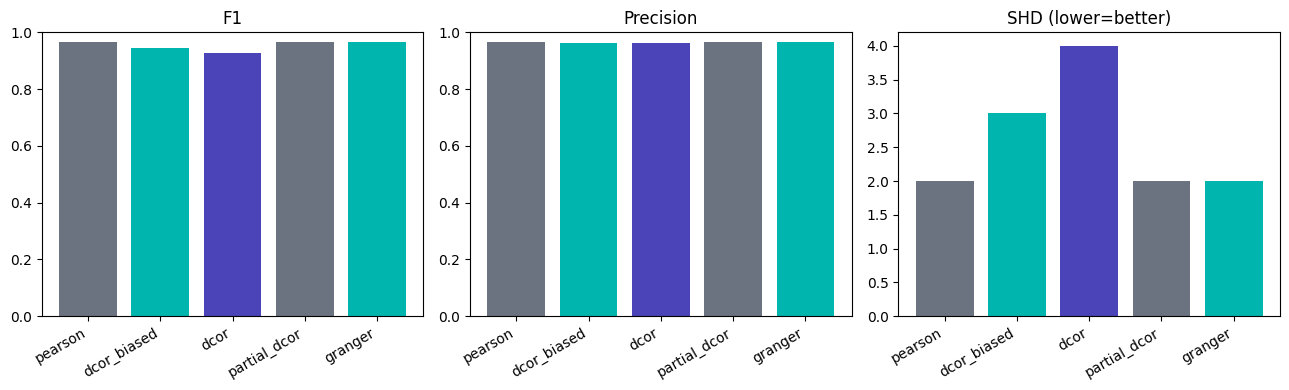

  lag_method       F1  Precision   Recall  SHD  n_tests     Time
     pearson 0.964286   0.964286 0.964286    2      194 0.162006
 dcor_biased 0.945455   0.962963 0.928571    3      226 0.108050
        dcor 0.925926   0.961538 0.892857    4      110 0.072794
partial_dcor 0.964286   0.964286 0.964286    2      194 0.056798
     granger 0.964286   0.964286 0.964286    2      194 0.055390


In [5]:
df_res = pd.DataFrame(records)
colors = ["#6b7280", "#00B5AD", "#4B44B8"]
x = np.arange(len(lag_methods))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, ["F1", "Precision", "SHD"],
                           ["F1", "Precision", "SHD (lower=better)"]):
    ax.bar(x, df_res[col], color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(lag_methods, rotation=30, ha="right")
    ax.set_title(title)
    if col != "SHD":
        ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(df_res[["lag_method", "F1", "Precision", "Recall", "SHD", "n_tests", "Time"]].to_string(index=False))


## 2. Compare `lag_pvalue_method`

`t_test` is analytic and ~200× faster than permutation. `circular_shift` runs permutations
that preserve the AR autocorrelation — better calibrated FPR in isolation, but interacts
poorly with the global BH-FDR correction applied over all d² × max_lag hypotheses:

> **Why `circular_shift` finds zero edges here:** With 200 permutations the minimum
> achievable p-value is 1/201 ≈ 0.005. BH-FDR across 484 hypotheses (11² × 4 lags) requires
> the top-ranked p-value to be < α × 1/484 ≈ 0.0001. Since 0.005 >> 0.0001, *every* lag is
> rejected after correction. This is not a bug — it is a genuine over-conservation of
> permutation tests under global multi-testing correction at moderate d.
>
> **Workaround:** increase `n_permutations` (≥ 20 000 to reach p < 0.0001) or use `t_test`
> (analytic, not limited by discrete p-values).


In [6]:
pvalue_methods = ["t_test", "circular_shift"]
records_pv = []

for pv_method in pvalue_methods:
    ci = PartialCorr(np.ascontiguousarray(df.values))
    t0 = time.time()
    res = run_cedar(
        df=df, ci_test=ci, max_lag=3,
        lag_method="dcor",
        lag_pvalue_method=pv_method,
        alpha_cond1=0.05, alpha_cond2=0.05,
    )
    elapsed = time.time() - t0

    m = evaluate_graph(res.cg_tig, ground_truth)  # includes AR self-loops
    records_pv.append(dict(
        lag_pvalue_method=pv_method,
        F1=m["F1"], Precision=m["Precision"], Recall=m["TPR"],
        SHD=m["SHD"], edges=int(res.cg_tig.sum()),
        n_tests=res.n_tests, Time=elapsed,
    ))
    print(f"{pv_method:<16} F1={m['F1']:.3f}  Prec={m['Precision']:.3f}  "
          f"Recall={m['TPR']:.3f}  SHD={m['SHD']}  edges={int(res.cg_tig.sum())}  ({elapsed:.2f}s)")

print()
print(pd.DataFrame(records_pv)[
    ["lag_pvalue_method","F1","Precision","Recall","SHD","edges","n_tests","Time"]
].to_string(index=False))
print()
print("Note: circular_shift finds 0 edges because BH-FDR over d²×max_lag hypotheses")
print("      requires p < 0.0001, but 200 permutations can only produce p ≥ 0.005.")
print("      Use t_test (default) or increase n_permutations ≥ 20 000 for circular_shift.")


t_test           F1=0.926  Prec=0.962  Recall=0.893  SHD=4  edges=26  (0.07s)
circular_shift   F1=0.564  Prec=1.000  Recall=0.393  SHD=17  edges=11  (5.67s)

lag_pvalue_method       F1  Precision   Recall  SHD  edges  n_tests     Time
           t_test 0.925926   0.961538 0.892857    4     26      110 0.074159
   circular_shift 0.564103   1.000000 0.392857   17     11        0 5.671990

Note: circular_shift finds 0 edges because BH-FDR over d²×max_lag hypotheses
      requires p < 0.0001, but 200 permutations can only produce p ≥ 0.005.
      Use t_test (default) or increase n_permutations ≥ 20 000 for circular_shift.


## Recommendations

**`lag_method`:**

| Method | Use when |
|---|---|
| `partial_dcor` | **Default** — removes AR-mediated lag inflation; best overall, especially hub-heavy graphs |
| `dcor` | Alternative for general nonlinear data |
| `dcor_biased` | Marginal speed advantage over `dcor` |
| `pearson` | Data is confirmed linear (see Ramsey RESET below); fastest |
| `granger` | Source has strong AR and inflates longer-lag scores even after residualisation |

**`lag_pvalue_method`:**

| Method | Use when |
|---|---|
| `t_test` | **Default** — analytic, ~200× faster; use for all standard settings |
| `circular_shift` | Only if d is small (< 5) or FDR correction is disabled; needs n_permutations ≥ 20 000 to survive BH-FDR at moderate d |

In [7]:
from causalts.utils.linearity import check_linearity

# RESET test conditions on Y_j(t-1) to absorb VAR autocorrelation,
# avoiding the inflated false positive rate of simple bivariate regressions.
lin_report = check_linearity(df)
results_lin = lin_report.get("results", [])
n_nonlinear = sum(1 for r in results_lin if r.get("is_nonlinear", False))
total = len(results_lin)
print(f"Ramsey RESET (AR-controlled): {n_nonlinear}/{total} pairs show significant nonlinearity")
print("→ Use 'dcor'" if n_nonlinear / total > 0.05 else "→ 'pearson' sufficient (data appears linear)")


Ramsey RESET (AR-controlled): 2/220 pairs show significant nonlinearity
→ 'pearson' sufficient (data appears linear)
